# Thumbnail Visualization Pipeline — 5개 카테고리

`YT_dataset_*.csv` 다섯 종류에 대해 **DINOv2-base**, **SigLIP2-base**로 영상(썸네일) 단위 임베딩을 추출한 뒤,  
**같은 채널의 벡터를 평균**내어 **채널당 벡터 1개**로 만듭니다.  
이후 **UMAP**과 **t-SNE**로 2차원 시각화합니다 (단색 scatter).

## 파이프라인 단계

```
Step 1: prepare   → 썸네일 경로 검증, dataset_ready.csv
Step 2: extract   → dinov2-base, siglip2-base (영상 단위 embeddings.npy)
Step 3: aggregate → 채널별 평균 벡터 channel_embeddings.npy
Step 4: visualize → UMAP / t-SNE (채널 단위)
```

## 산출 (카테고리별)

```
artifacts/{카테고리}/embeddings/{모델}/
  embeddings.npy          # 영상 단위 (원본)
  metadata.csv
  channel_embeddings.npy  # 채널 단위 (평균 + L2 정규화)
  channel_metadata.csv
artifacts/{카테고리}/visualizations/{모델}/  umap.png, tsne_perp*.png


---
## 라이브러리 & 전역 설정


In [1]:
from __future__ import annotations

import csv
import json
import os
import re

# Windows에서 PyTorch·NumPy 등이 동시에 OpenMP를 쓸 때 나는 libiomp5 충돌 완화
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import sys
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

# ── 작업 디렉터리 (프로젝트 루트) ──
_marker = Path("YT_dataset_health.csv")
if not _marker.exists():
    for p in Path.cwd().rglob("YT_dataset_health.csv"):
        os.chdir(p.parent)
        break
print(f"CWD: {Path.cwd()}")

# ── 5개 데이터셋 (카테고리 키, CSV 경로) ──
DATASETS: List[Tuple[str, Path]] = [
    ("health",    Path("YT_dataset_health.csv")),
    ("food",      Path("YT_dataset_food.csv")),
    ("VLOG",      Path("YT_dataset_VLOG.csv")),
    ("society",   Path("YT_dataset_society.csv")),
    ("education", Path("YT_dataset_education.csv")),
]

ARTIFACTS_BASE = Path("artifacts")

# ── 모델 ──
MODEL_ALIASES = {
    "dinov2-base":  "facebook/dinov2-base",
    "siglip2-base": "google/siglip2-base-patch16-224",
}
MODELS_TO_RUN = "dinov2-base,siglip2-base"
BATCH_SIZE    = 32
DEVICE        = "cuda"   # "cuda" | "cpu" | "auto" (GPU 없으면 cuda는 오류 → cpu 또는 auto)

UMAP_NEIGHBORS    = 20
UMAP_MIN_DIST     = 0.1
TSNE_PERPLEXITIES = [5, 15, 30]

print("설정 완료")
print(f"  카테고리: {[c for c, _ in DATASETS]}")
print(f"  모델: {MODELS_TO_RUN}")
print(f"  디바이스: {DEVICE}")
print(f"  산출 루트: {ARTIFACTS_BASE}/{{카테고리}}/")


CWD: g:\내 드라이브\0. 포트폴리오\프로젝트\[260302-260631] 26-1 URP
설정 완료
  카테고리: ['health', 'food', 'VLOG', 'society', 'education']
  모델: dinov2-base,siglip2-base
  디바이스: cuda
  산출 루트: artifacts/{카테고리}/


---
## 공통 유틸리티 함수


In [2]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def read_csv_rows(path: Path, encoding: str = "utf-8-sig") -> List[Dict[str, str]]:
    with path.open("r", encoding=encoding, newline="") as f:
        return list(csv.DictReader(f))


def write_csv_rows(
    path: Path,
    fieldnames: Sequence[str],
    rows: Iterable[Dict],
) -> None:
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


print("유틸리티 함수 정의 완료")


유틸리티 함수 정의 완료


---
## Step 1: 데이터 준비 (`prepare`)

각 카테고리 CSV에서 **썸네일 파일이 존재하는 행만** `artifacts/{카테고리}/dataset_ready.csv`로 저장합니다.


In [3]:
def prepare_dataset(youtube_csv: Path, output_dir: Path) -> None:
    ensure_dir(output_dir)
    rows = read_csv_rows(youtube_csv)

    ready, skipped_no_path, skipped_missing = [], 0, 0
    for row in rows:
        thumb_str = (row.get("thumbnail_path") or "").strip()
        if not thumb_str:
            skipped_no_path += 1
            continue
        thumb = Path(thumb_str)
        if not thumb.exists():
            skipped_missing += 1
            continue
        ready.append({
            "channel_name":   (row.get("channel_name")  or "").strip(),
            "channel_id":     (row.get("channel_id")    or "").strip(),
            "video_id":       (row.get("video_id")      or "").strip(),
            "title":          (row.get("title")         or "").strip(),
            "published_at":   (row.get("published_at")  or "").strip(),
            "duration":       (row.get("duration")      or "").strip(),
            "thumbnail_path": thumb_str,
            "thumbnail_url":  (row.get("thumbnail_url") or "").strip(),
        })

    fieldnames = [
        "channel_name", "channel_id", "video_id",
        "title", "published_at", "duration",
        "thumbnail_path", "thumbnail_url",
    ]
    write_csv_rows(output_dir / "dataset_ready.csv", fieldnames, ready)

    summary = {
        "source_csv":        str(youtube_csv),
        "total_input":       len(rows),
        "skipped_no_path":   skipped_no_path,
        "skipped_missing":   skipped_missing,
        "ready_count":       len(ready),
    }
    with (output_dir / "prepare_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f"[{output_dir.name}] 입력 {len(rows)} → 준비 {len(ready)} (경로없음 {skipped_no_path}, 파일없음 {skipped_missing})")


print("prepare 함수 정의 완료")


prepare 함수 정의 완료


In [4]:
# ── Step 1 실행 (5개 카테고리) ──
for cat, csv_path in DATASETS:
    if not csv_path.exists():
        print(f"[{cat}] 건너뜀 — 파일 없음: {csv_path}")
        continue
    out = ARTIFACTS_BASE / cat
    prepare_dataset(youtube_csv=csv_path, output_dir=out)


[health] 입력 7759 → 준비 7759 (경로없음 0, 파일없음 0)
[food] 입력 8538 → 준비 8536 (경로없음 2, 파일없음 0)
[VLOG] 입력 7710 → 준비 7709 (경로없음 1, 파일없음 0)
[society] 입력 8369 → 준비 8366 (경로없음 3, 파일없음 0)
[education] 입력 8424 → 준비 8424 (경로없음 0, 파일없음 0)


---
## Step 2: 임베딩 추출 (`extract`)

카테고리별 `dataset_ready.csv`에 대해 **dinov2-base**, **siglip2-base** 순으로 임베딩을 저장합니다.

> GPU 사용: `DEVICE = "cuda"`


In [5]:
import numpy as np
from PIL import Image


@dataclass
class LoadedModel:
    model_id:  str
    alias:     str
    processor: object
    model:     object
    device:    str


def _resolve_device(requested: str) -> str:
    if requested != "auto":
        return requested
    try:
        import torch
        if torch.cuda.is_available():
            return "cuda"
    except Exception:
        pass
    return "cpu"


def _resolve_model_id(alias_or_id: str) -> Tuple[str, str]:
    alias_or_id = alias_or_id.strip()
    if alias_or_id in MODEL_ALIASES:
        return alias_or_id, MODEL_ALIASES[alias_or_id]
    safe_alias = re.sub(r"[^a-zA-Z0-9._-]+", "_", alias_or_id)
    return safe_alias, alias_or_id


def _load_transformers_model(alias_or_id: str, device: str) -> LoadedModel:
    from transformers import AutoImageProcessor, AutoModel, AutoProcessor
    alias, model_id = _resolve_model_id(alias_or_id)
    model = AutoModel.from_pretrained(model_id)
    try:
        processor = AutoProcessor.from_pretrained(model_id)
    except Exception:
        processor = AutoImageProcessor.from_pretrained(model_id)
    model = model.to(device).eval()
    return LoadedModel(model_id=model_id, alias=alias,
                       processor=processor, model=model, device=device)


def _extract_batch_embeddings(loaded: LoadedModel, images: list) -> list:
    import torch

    inputs = loaded.processor(images=images, return_tensors="pt")
    inputs = {
        k: v.to(loaded.device)
        for k, v in inputs.items()
        if isinstance(v, torch.Tensor)
    }
    model = loaded.model
    mid = (loaded.model_id or "").lower()

    with torch.no_grad():
        # SigLIP / SigLIP2: model(**inputs) 는 input_ids 없으면 오류 → 이미지 전용 경로
        if "siglip" in mid:
            pixel_values = inputs.get("pixel_values")
            if pixel_values is None:
                raise ValueError("SigLIP 계열은 pixel_values가 필요합니다.")
            getter = getattr(model, "get_image_features", None)
            if callable(getter):
                feats = getter(pixel_values=pixel_values)
            elif hasattr(model, "vision_model"):
                vout = model.vision_model(pixel_values=pixel_values)
                feats = getattr(vout, "pooler_output", None)
                if feats is None:
                    feats = vout.last_hidden_state[:, 0, :]
            else:
                raise RuntimeError("SigLIP: get_image_features / vision_model 없음")
        else:
            outputs = model(**inputs)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                feats = outputs.pooler_output
            else:
                feats = outputs.last_hidden_state[:, 0, :]

    # SigLIP2 등: get_image_features가 Tensor 대신 BaseModelOutputWithPooling 등을 반환할 수 있음
    if not isinstance(feats, torch.Tensor):
        po = getattr(feats, "pooler_output", None)
        if po is not None:
            feats = po
        elif getattr(feats, "last_hidden_state", None) is not None:
            feats = feats.last_hidden_state[:, 0, :]
        else:
            raise TypeError(f"임베딩 텐서로 변환할 수 없습니다: {type(feats)}")

    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy().tolist()


def extract_embeddings(
    dataset_csv: Path,
    output_root: Path,
    models: str = MODELS_TO_RUN,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
) -> None:
    ensure_dir(output_root)
    rows = read_csv_rows(dataset_csv, encoding="utf-8")

    if not rows:
        raise RuntimeError(f"데이터가 없습니다: {dataset_csv}")

    device_str  = _resolve_device(device)
    model_specs = [m.strip() for m in models.split(",") if m.strip()]
    print(f"추출 대상: {len(rows)}행 | 디바이스: {device_str} | 모델: {model_specs}")

    for model_name in model_specs:
        print(f"\n[{model_name}] 모델 로드 중...")
        loaded    = _load_transformers_model(model_name, device=device_str)
        model_dir = output_root / loaded.alias
        ensure_dir(model_dir)

        all_embs, all_meta = [], []
        batch_imgs, batch_meta_buf = [], []

        def flush():
            if not batch_imgs:
                return
            for i, emb in enumerate(_extract_batch_embeddings(loaded, batch_imgs)):
                all_embs.append(emb)
                all_meta.append(batch_meta_buf[i])
            batch_imgs.clear()
            batch_meta_buf.clear()

        missing_thumb = 0
        for row in rows:
            thumb = Path(row["thumbnail_path"])
            if not thumb.exists():
                missing_thumb += 1
                continue
            try:
                img = Image.open(thumb).convert("RGB")
            except Exception:
                continue
            batch_imgs.append(img)
            batch_meta_buf.append({
                "video_id":       row.get("video_id", ""),
                "channel_id":     row.get("channel_id", ""),
                "channel_name":   row.get("channel_name", ""),
                "published_at":   row.get("published_at", ""),
                "duration":       row.get("duration", ""),
                "thumbnail_path": row.get("thumbnail_path", ""),
            })
            if len(batch_imgs) >= batch_size:
                flush()
        flush()

        if missing_thumb:
            print(f"  썸네일 파일 없음(건너뜀): {missing_thumb}개")
        if not all_embs:
            print(f"  [{model_name}] 임베딩 없음, 건너뜀")
            continue

        embeddings = np.stack(all_embs, axis=0)
        np.save(model_dir / "embeddings.npy", embeddings)

        meta_fields = ["video_id", "channel_id", "channel_name",
                       "published_at", "duration", "thumbnail_path"]
        write_csv_rows(model_dir / "metadata.csv", meta_fields, all_meta)

        run_info = {
            "alias": loaded.alias, "model_id": loaded.model_id, "device": device_str,
            "batch_size": batch_size, "rows_input": len(rows),
            "rows_embedded": int(embeddings.shape[0]),
            "embedding_dim": int(embeddings.shape[1]),
        }
        with (model_dir / "run_info.json").open("w", encoding="utf-8") as f:
            json.dump(run_info, f, ensure_ascii=False, indent=2)

        print(f"  임베딩 shape: {embeddings.shape} → {model_dir / 'embeddings.npy'}")


print("extract 함수 정의 완료")


extract 함수 정의 완료


In [6]:
# ── Step 2 실행 (5개 카테고리 × 2모델) ──
for cat, _ in DATASETS:
    ready = ARTIFACTS_BASE / cat / "dataset_ready.csv"
    if not ready.exists():
        print(f"[{cat}] dataset_ready.csv 없음, 건너뜀")
        continue
    emb_root = ARTIFACTS_BASE / cat / "embeddings"
    print(f"\n========== [{cat}] 임베딩 추출 ==========")
    extract_embeddings(
        dataset_csv=ready,
        output_root=emb_root,
        models=MODELS_TO_RUN,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )



========== [health] 임베딩 추출 ==========
추출 대상: 7759행 | 디바이스: cuda | 모델: ['dinov2-base', 'siglip2-base']

[dinov2-base] 모델 로드 중...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  임베딩 shape: (7759, 768) → artifacts\health\embeddings\dinov2-base\embeddings.npy

[siglip2-base] 모델 로드 중...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

  임베딩 shape: (7759, 768) → artifacts\health\embeddings\siglip2-base\embeddings.npy

========== [food] 임베딩 추출 ==========
추출 대상: 8536행 | 디바이스: cuda | 모델: ['dinov2-base', 'siglip2-base']

[dinov2-base] 모델 로드 중...


...

  임베딩 shape: (8366, 768) → artifacts\society\embeddings\siglip2-base\embeddings.npy

========== [education] 임베딩 추출 ==========
추출 대상: 8424행 | 디바이스: cuda | 모델: ['dinov2-base', 'siglip2-base']

[dinov2-base] 모델 로드 중...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  임베딩 shape: (8424, 768) → artifacts\education\embeddings\dinov2-base\embeddings.npy

[siglip2-base] 모델 로드 중...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

  임베딩 shape: (8424, 768) → artifacts\education\embeddings\siglip2-base\embeddings.npy


---
## Step 3: 채널 평균 집계 (`aggregate`)

각 모델 폴더의 `embeddings.npy` + `metadata.csv`를 읽어 `channel_id`별로 **임베딩 행**에 대해 평균을 냅니다.  
평균 후 **L2 정규화**로 길이를 1로 맞추면, 코사인 유사도가 **내적**과 같아져 방향(의미) 위주로 비교하기 쉽습니다.

| 출력 | 설명 |
|---|---|
| `channel_embeddings.npy` | (채널 수, 768) |
| `channel_metadata.csv` | channel_id, channel_name, n_videos |

### 무엇을 평균하는가 (메타데이터 vs 임베딩)

- **평균 내는 것:** `embeddings.npy`의 **벡터만**입니다. 같은 `channel_id`에 속한 영상(행)들의 임베딩을 차원별로 더해 개수로 나눈 뒤, 채널당 하나의 벡터로 만듭니다.
- **`metadata.csv`의 역할:** 각 임베딩 행과 **같은 순서**로 `channel_id`(및 표시용 `channel_name`)를 붙여 **어느 행이 어느 채널인지** 구분합니다. CSV 안의 숫자·텍스트 컬럼을 “평균”하지는 않습니다.
- **`channel_metadata.csv`에 쓰이는 값:**
  - `channel_id`: 그룹 키
  - `channel_name`: 같은 채널을 순회하며 마지막으로 본 행의 이름(보통 채널마다 동일). **이름 자체를 평균 내지는 않음**
  - `n_videos`: 해당 채널에 묶인 영상 **개수**(평균이 아님)

정리하면, Step 3는 **“메타데이터 평균”이 아니라 “채널별 임베딩 평균 + 채널 단위 메타 요약”**입니다.


In [7]:
def aggregate_embeddings_by_channel(model_dir: Path) -> None:
    """embeddings.npy + metadata.csv → channel_embeddings.npy (채널당 1행)."""
    import numpy as np
    from collections import defaultdict

    emb_path = model_dir / "embeddings.npy"
    meta_path = model_dir / "metadata.csv"
    if not emb_path.exists() or not meta_path.exists():
        print(f"  건너뜀 (파일 없음): {model_dir.name}")
        return

    X = np.load(emb_path)
    meta = read_csv_rows(meta_path, encoding="utf-8")
    if len(meta) != X.shape[0]:
        raise RuntimeError(f"행 수 불일치: {model_dir} embeddings {X.shape[0]} vs metadata {len(meta)}")

    groups: dict[str, list[int]] = defaultdict(list)
    ch_name: dict[str, str] = {}
    for i, row in enumerate(meta):
        cid = (row.get("channel_id") or "").strip()
        if not cid:
            continue
        groups[cid].append(i)
        ch_name[cid] = (row.get("channel_name") or "").strip()

    if not groups:
        print(f"  [{model_dir.name}] channel_id 없음")
        return

    cids = sorted(groups.keys())
    X_ch = np.stack([X[groups[c]].mean(axis=0) for c in cids], axis=0)
    norms = np.linalg.norm(X_ch, axis=1, keepdims=True)
    norms = np.where(norms < 1e-12, 1.0, norms)
    X_ch = X_ch / norms

    np.save(model_dir / "channel_embeddings.npy", X_ch)

    rows_out = [
        {"channel_id": c, "channel_name": ch_name.get(c, ""), "n_videos": str(len(groups[c]))}
        for c in cids
    ]
    write_csv_rows(
        model_dir / "channel_metadata.csv",
        ["channel_id", "channel_name", "n_videos"],
        rows_out,
    )
    with (model_dir / "channel_aggregate_summary.json").open("w", encoding="utf-8") as f:
        json.dump(
            {"n_channels": len(cids), "embedding_dim": int(X_ch.shape[1])},
            f,
            ensure_ascii=False,
            indent=2,
        )
    print(f"  [{model_dir.name}] 채널 {len(cids)}개 ← 영상 {X.shape[0]}개")


def aggregate_category_embeddings(embeddings_root: Path) -> None:
    from tqdm.auto import tqdm

    model_dirs = sorted(p for p in embeddings_root.iterdir() if p.is_dir())
    for model_dir in tqdm(model_dirs, desc="  모델별 집계", unit="모델", leave=False):
        aggregate_embeddings_by_channel(model_dir)


print("aggregate 함수 정의 완료")


aggregate 함수 정의 완료


In [8]:
# ── Step 3 실행 (5개 카테고리 × 각 모델 폴더) ──
# tqdm: 진행률·경과 시간·남은 시간(ETA) 표시 (주피터/터미널 모두 tqdm.auto)
from tqdm.auto import tqdm

step3_jobs: list[tuple[str, Path]] = []
for cat, _ in DATASETS:
    emb_root = ARTIFACTS_BASE / cat / "embeddings"
    if not emb_root.is_dir():
        print(f"[{cat}] embeddings 폴더 없음")
        continue
    step3_jobs.append((cat, emb_root))

for cat, emb_root in tqdm(step3_jobs, desc="Step3 채널 평균", unit="카테고리"):
    tqdm.write(f"\n========== [{cat}] 채널 평균 집계 ==========")
    aggregate_category_embeddings(emb_root)


Step3 채널 평균:   0%|          | 0/5 [00:00<?, ?카테고리/s]


========== [health] 채널 평균 집계 ==========


  모델별 집계:   0%|          | 0/2 [00:00<?, ?모델/s]

  [dinov2-base] 채널 787개 ← 영상 7759개
  [siglip2-base] 채널 787개 ← 영상 7759개

========== [food] 채널 평균 집계 ==========


  모델별 집계:   0%|          | 0/2 [00:00<?, ?모델/s]

...

  [dinov2-base] 채널 784개 ← 영상 7709개
  [siglip2-base] 채널 784개 ← 영상 7709개

========== [society] 채널 평균 집계 ==========


  모델별 집계:   0%|          | 0/2 [00:00<?, ?모델/s]

  [dinov2-base] 채널 845개 ← 영상 8366개
  [siglip2-base] 채널 845개 ← 영상 8366개

========== [education] 채널 평균 집계 ==========


  모델별 집계:   0%|          | 0/2 [00:00<?, ?모델/s]

  [dinov2-base] 채널 848개 ← 영상 8424개
  [siglip2-base] 채널 848개 ← 영상 8424개


---
## Step 4: 시각화 (`visualize`)

**채널 단위** `channel_embeddings.npy`에 대해 단색 UMAP / t-SNE를 저장합니다.


In [9]:
def _scatter(path: Path, coords, title: str, color: str = "#4C72B0") -> None:
    """단색 2D scatter plot 저장."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(coords[:, 0], coords[:, 1], s=28, alpha=0.55, color=color, linewidths=0)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("dim-1")
    ax.set_ylabel("dim-2")
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.close(fig)
    print(f"  저장: {path}")


def visualize_category_models(
    category: str,
    embeddings_root: Path,
    output_dir: Path,
    umap_neighbors: int = UMAP_NEIGHBORS,
    umap_min_dist: float = UMAP_MIN_DIST,
    tsne_perplexities: List[int] = TSNE_PERPLEXITIES,
) -> None:
    import numpy as np
    import umap as umap_lib
    from sklearn.manifold import TSNE

    model_dirs = sorted([p for p in embeddings_root.iterdir() if p.is_dir()])
    if not model_dirs:
        print(f"[{category}] 임베딩 폴더 없음: {embeddings_root}")
        return

    ensure_dir(output_dir)

    for model_dir in model_dirs:
        ch_emb = model_dir / "channel_embeddings.npy"
        if not ch_emb.exists():
            print(f"[{category}/{model_dir.name}] channel_embeddings.npy 없음 → Step 3 집계를 먼저 실행하세요.")
            continue

        X = np.load(ch_emb)
        n = X.shape[0]
        print(f"\n[{category} / {model_dir.name}] 채널 임베딩 shape: {X.shape}")

        model_out = output_dir / model_dir.name
        ensure_dir(model_out)

        nn = min(umap_neighbors, max(2, n - 1))
        reducer = umap_lib.UMAP(
            n_components=2,
            n_neighbors=nn,
            min_dist=umap_min_dist,
            metric="cosine",
            random_state=42,
        )
        umap_coords = reducer.fit_transform(X)
        _scatter(
            model_out / "umap_channels.png",
            umap_coords,
            title=f"UMAP (채널 평균) — {category} / {model_dir.name} (n_channels={n})",
        )

        for p in tsne_perplexities:
            if p >= n:
                print(f"  t-SNE perp={p} 건너뜀 (채널 수 부족)")
                continue
            coords = TSNE(
                n_components=2,
                perplexity=p,
                init="pca",
                learning_rate="auto",
                random_state=42,
            ).fit_transform(X)
            _scatter(
                model_out / f"tsne_channels_perp{p}.png",
                coords,
                title=f"t-SNE perp={p} (채널 평균) — {category} / {model_dir.name} (n={n})",
            )

        summary = {
            "category": category,
            "model": model_dir.name,
            "level": "channel_mean",
            "n_channels": int(n),
            "embedding_dim": int(X.shape[1]),
        }
        with (model_out / "visualize_summary.json").open("w", encoding="utf-8") as f:
            json.dump(summary, f, ensure_ascii=False, indent=2)

    print(f"[{category}] 시각화 완료 → {output_dir}")


print("visualize 함수 정의 완료")


visualize 함수 정의 완료


In [10]:
# ── Step 4 실행 (5개 카테고리, 채널 단위 시각화) ──
for cat, _ in DATASETS:
    emb_root = ARTIFACTS_BASE / cat / "embeddings"
    viz_root = ARTIFACTS_BASE / cat / "visualizations"
    visualize_category_models(
        category=cat,
        embeddings_root=emb_root,
        output_dir=viz_root,
        umap_neighbors=UMAP_NEIGHBORS,
        umap_min_dist=UMAP_MIN_DIST,
        tsne_perplexities=TSNE_PERPLEXITIES,
    )



[health / dinov2-base] 채널 임베딩 shape: (787, 768)


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from f

  저장: artifacts\health\visualizations\dinov2-base\umap_channels.png


C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=180)
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from 

  저장: artifacts\health\visualizations\dinov2-base\tsne_channels_perp5.png


...

C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=180)
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from 

  저장: artifacts\education\visualizations\siglip2-base\tsne_channels_perp5.png


C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=180)
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from 

  저장: artifacts\education\visualizations\siglip2-base\tsne_channels_perp15.png
  저장: artifacts\education\visualizations\siglip2-base\tsne_channels_perp30.png
[education] 시각화 완료 → artifacts\education\visualizations


C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:9: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=180)
C:\Users\user\AppData\Local\Temp\ipykernel_57304\367337785.py:10: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from 

---
## 결과 인라인 확인

카테고리 → 모델별 **채널 단위** UMAP / t-SNE PNG (`umap_channels.png`, `tsne_channels_perp*.png`)를 표시합니다.



=== health / dinov2-base (채널 단위) ===


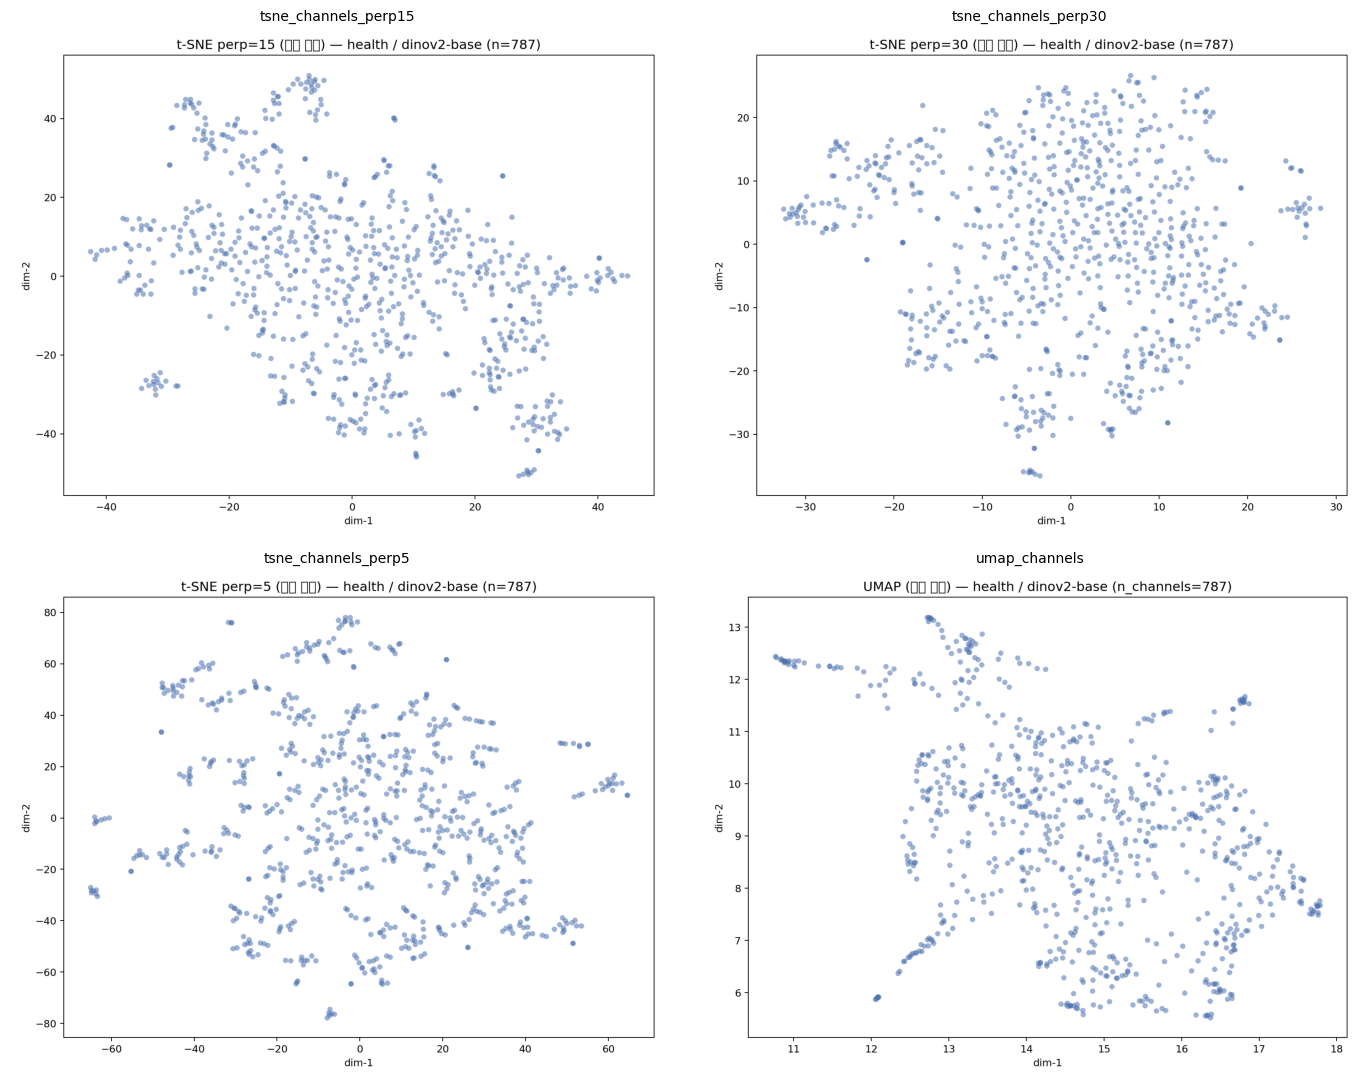


=== health / siglip2-base (채널 단위) ===


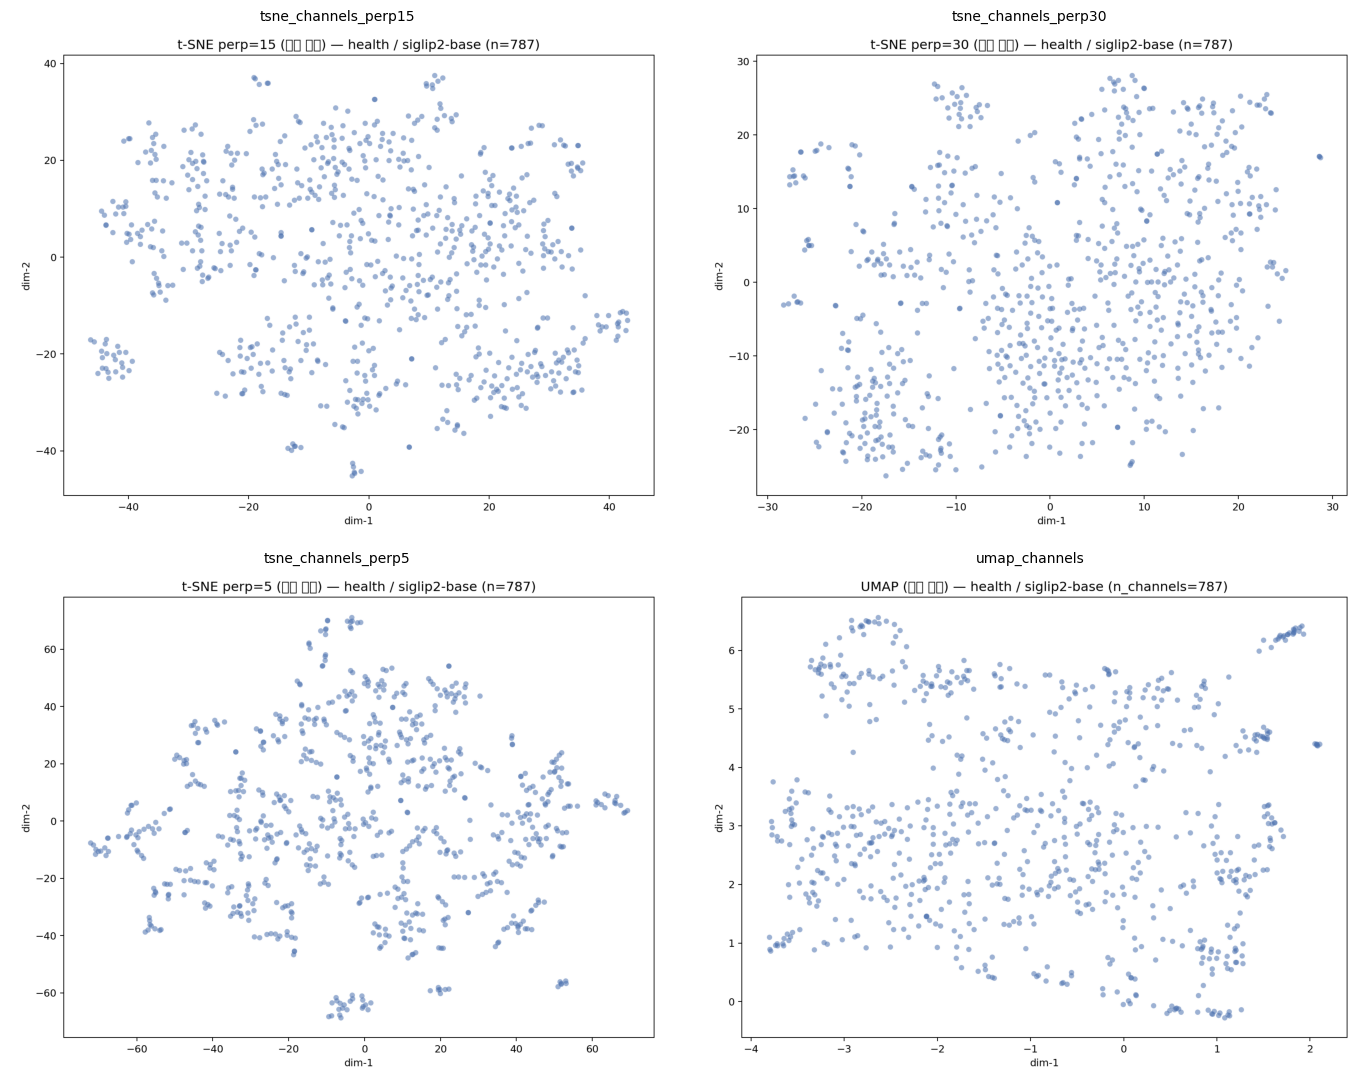


=== food / dinov2-base (채널 단위) ===


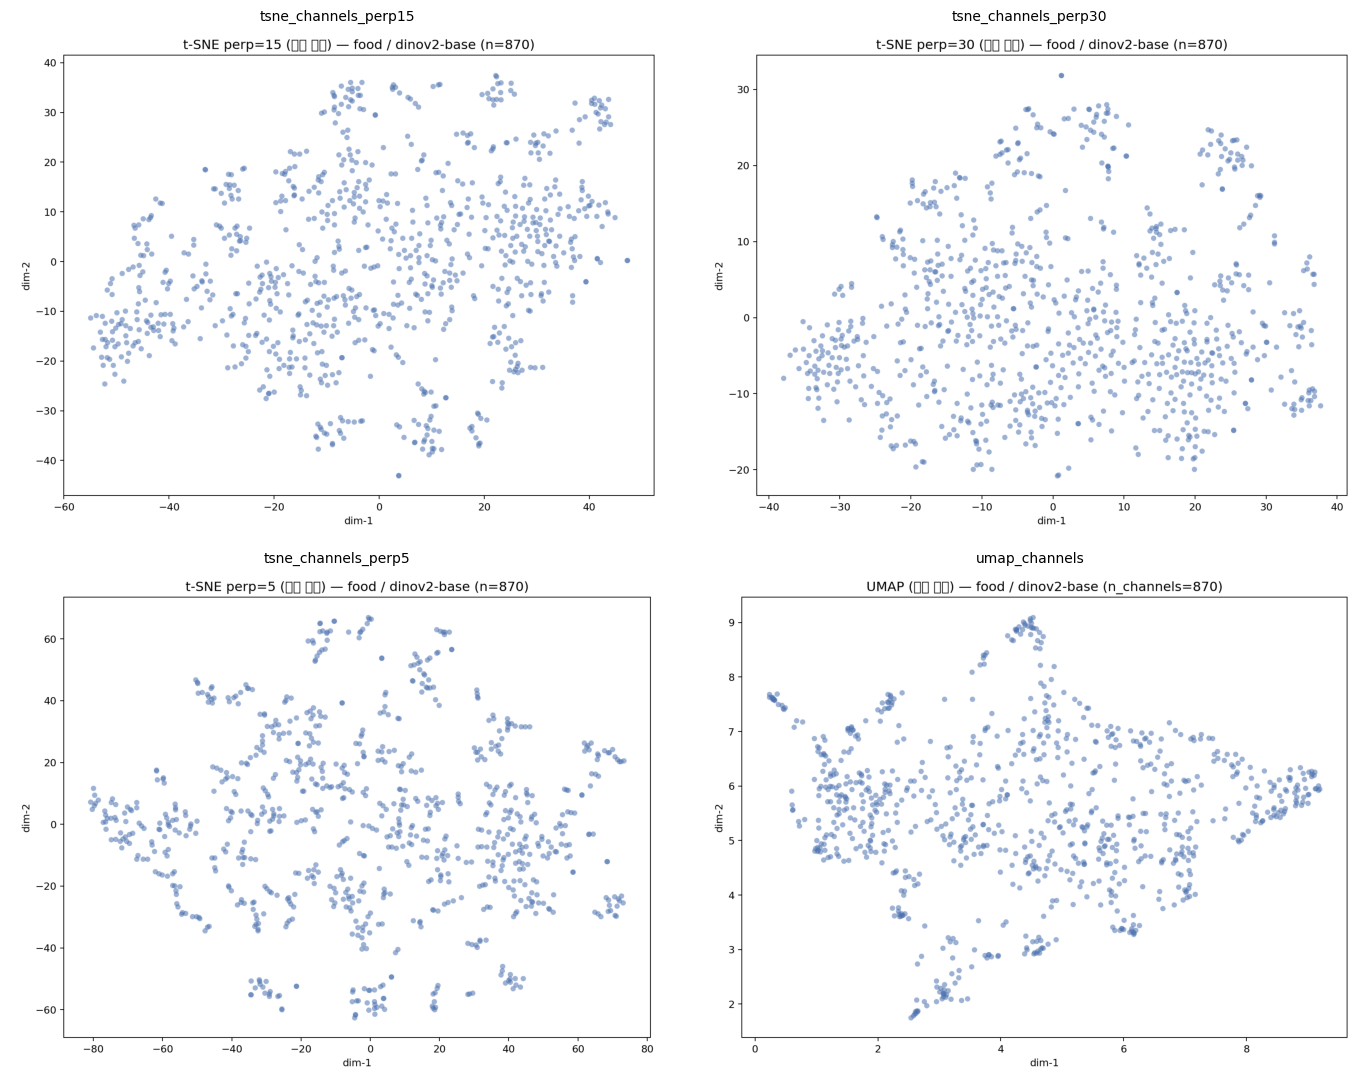


=== food / siglip2-base (채널 단위) ===


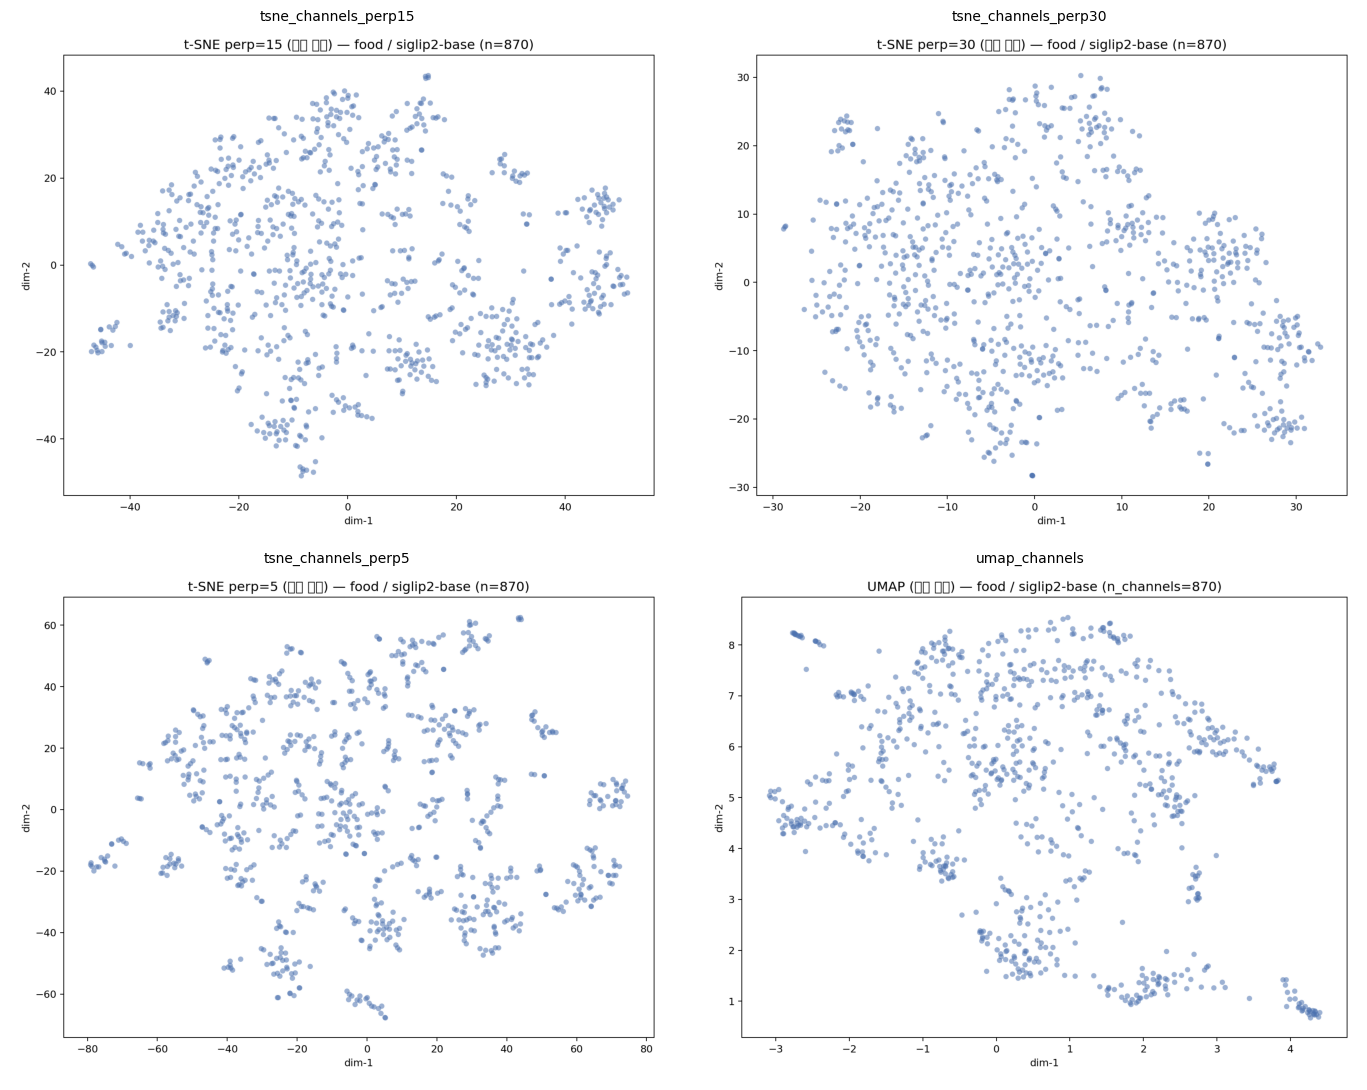


=== VLOG / dinov2-base (채널 단위) ===


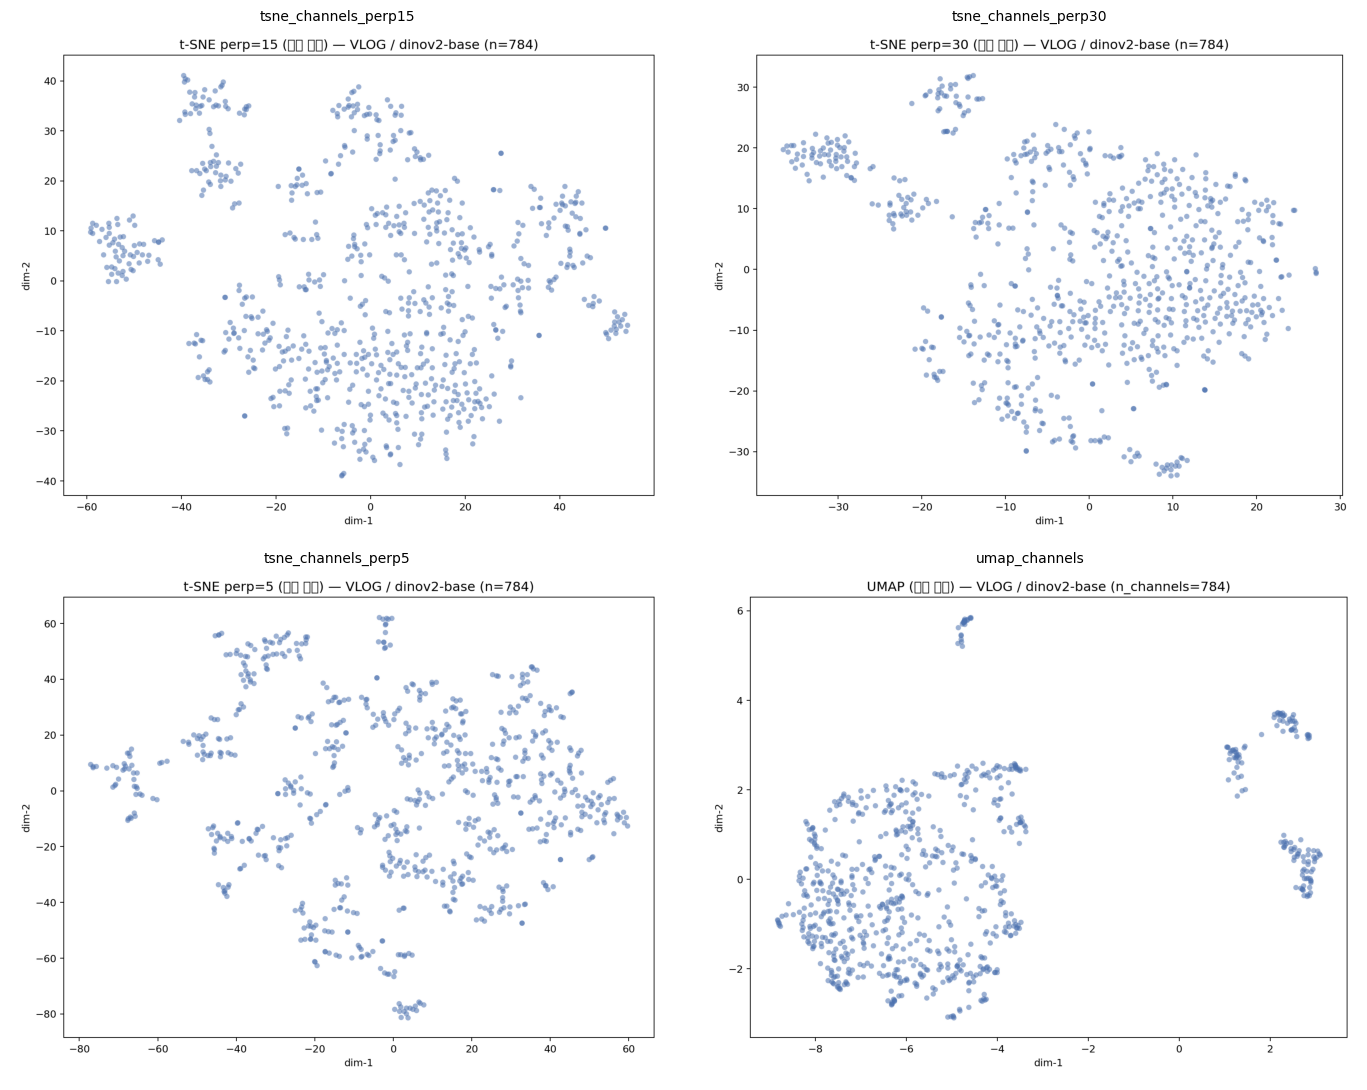


=== VLOG / siglip2-base (채널 단위) ===


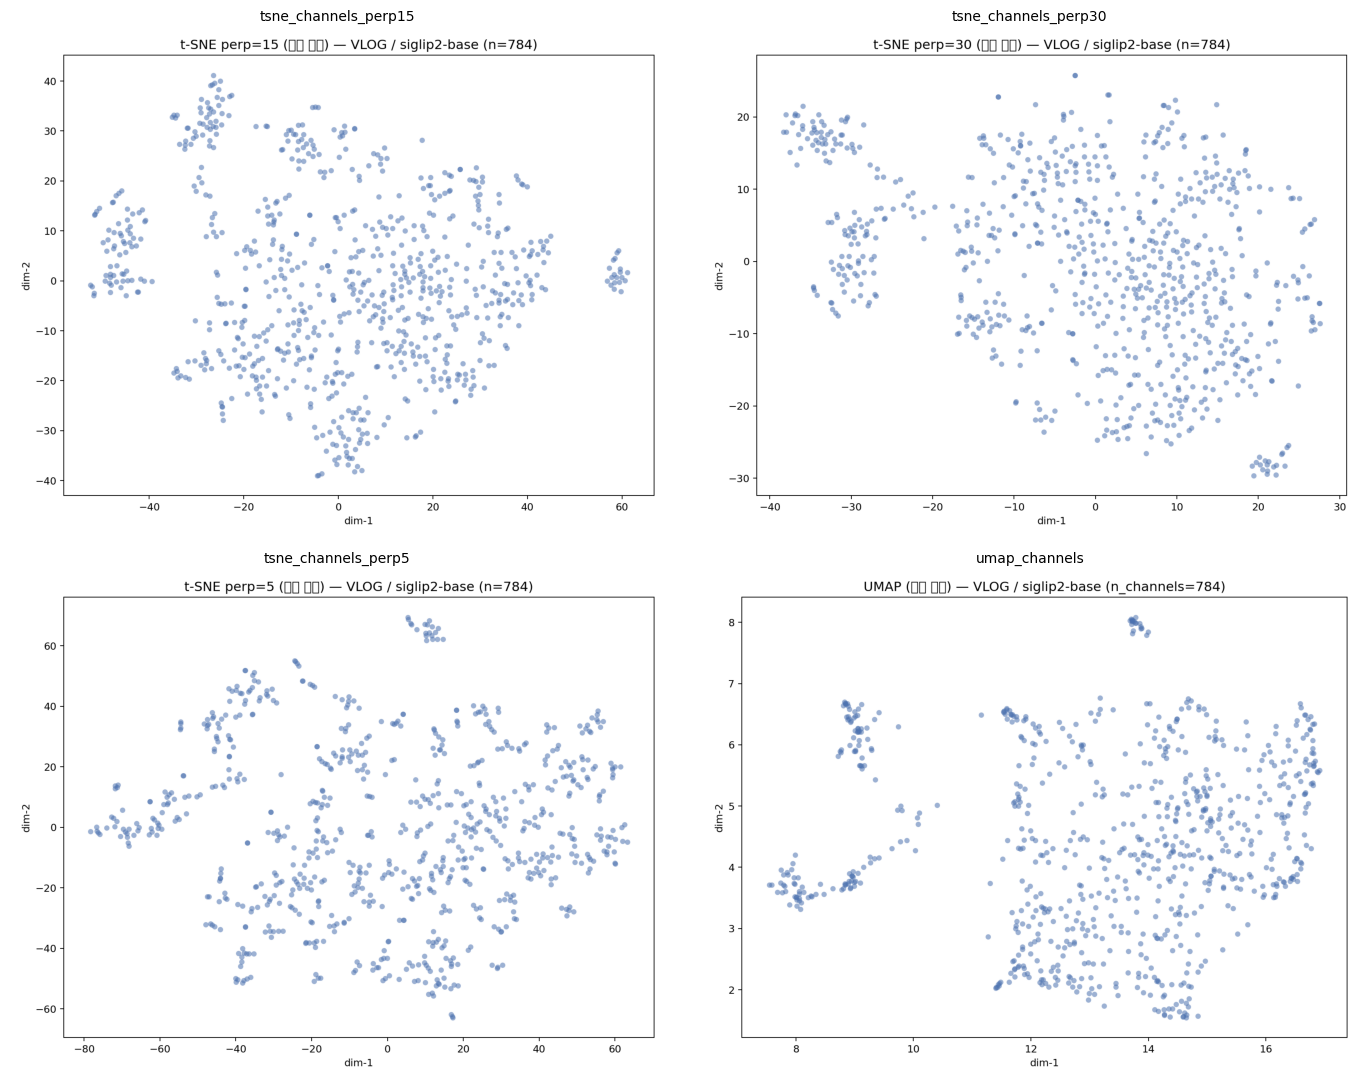


=== society / dinov2-base (채널 단위) ===


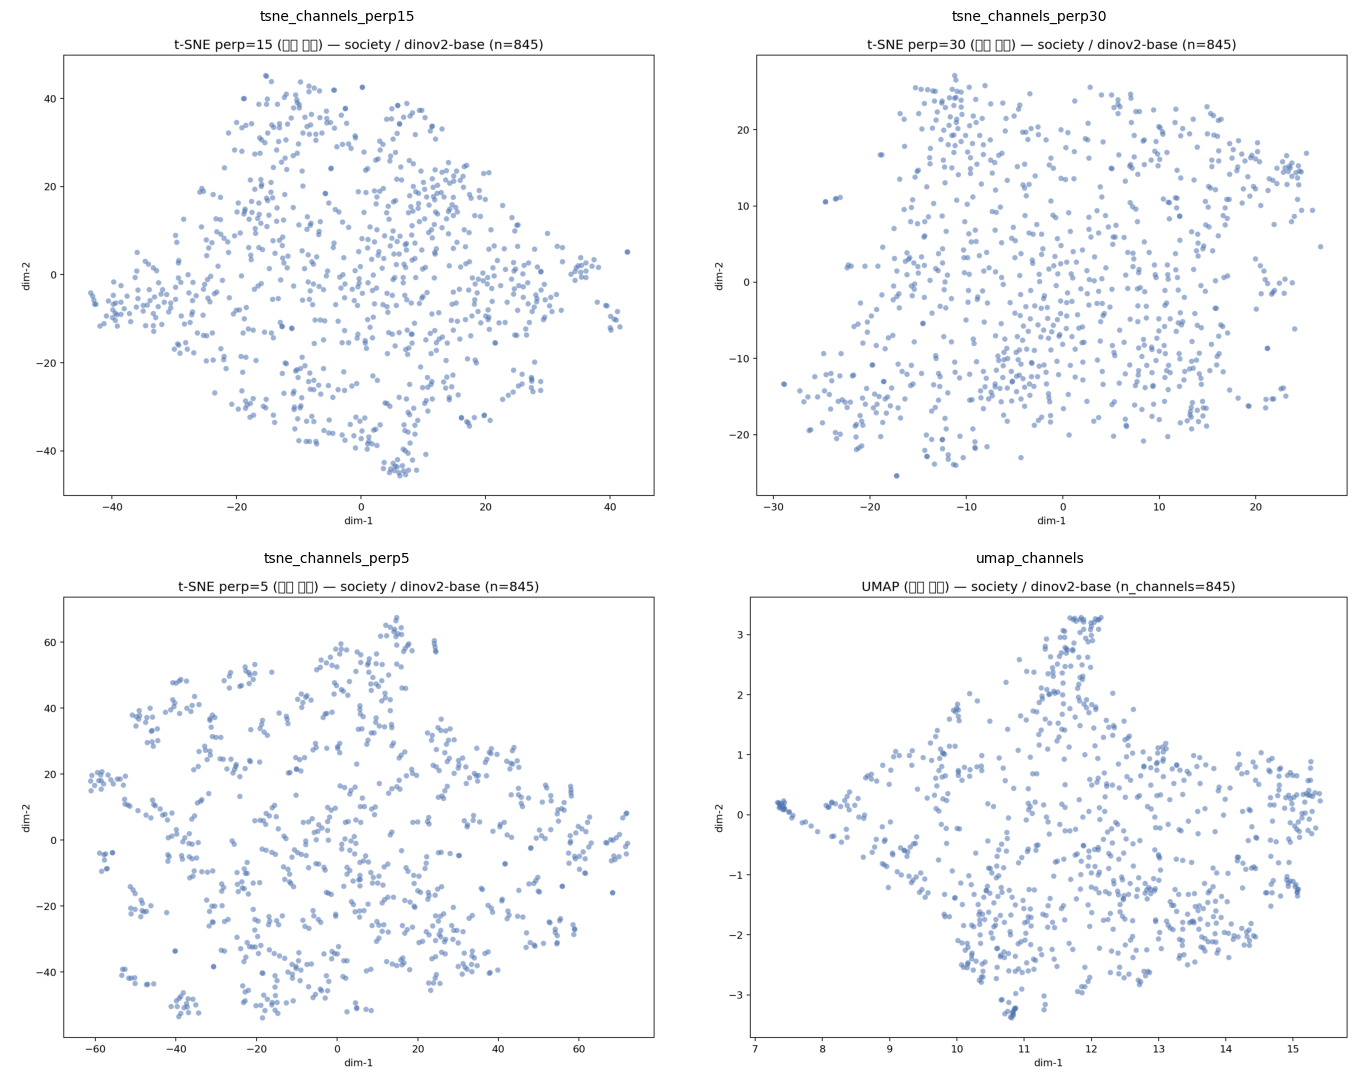


=== society / siglip2-base (채널 단위) ===


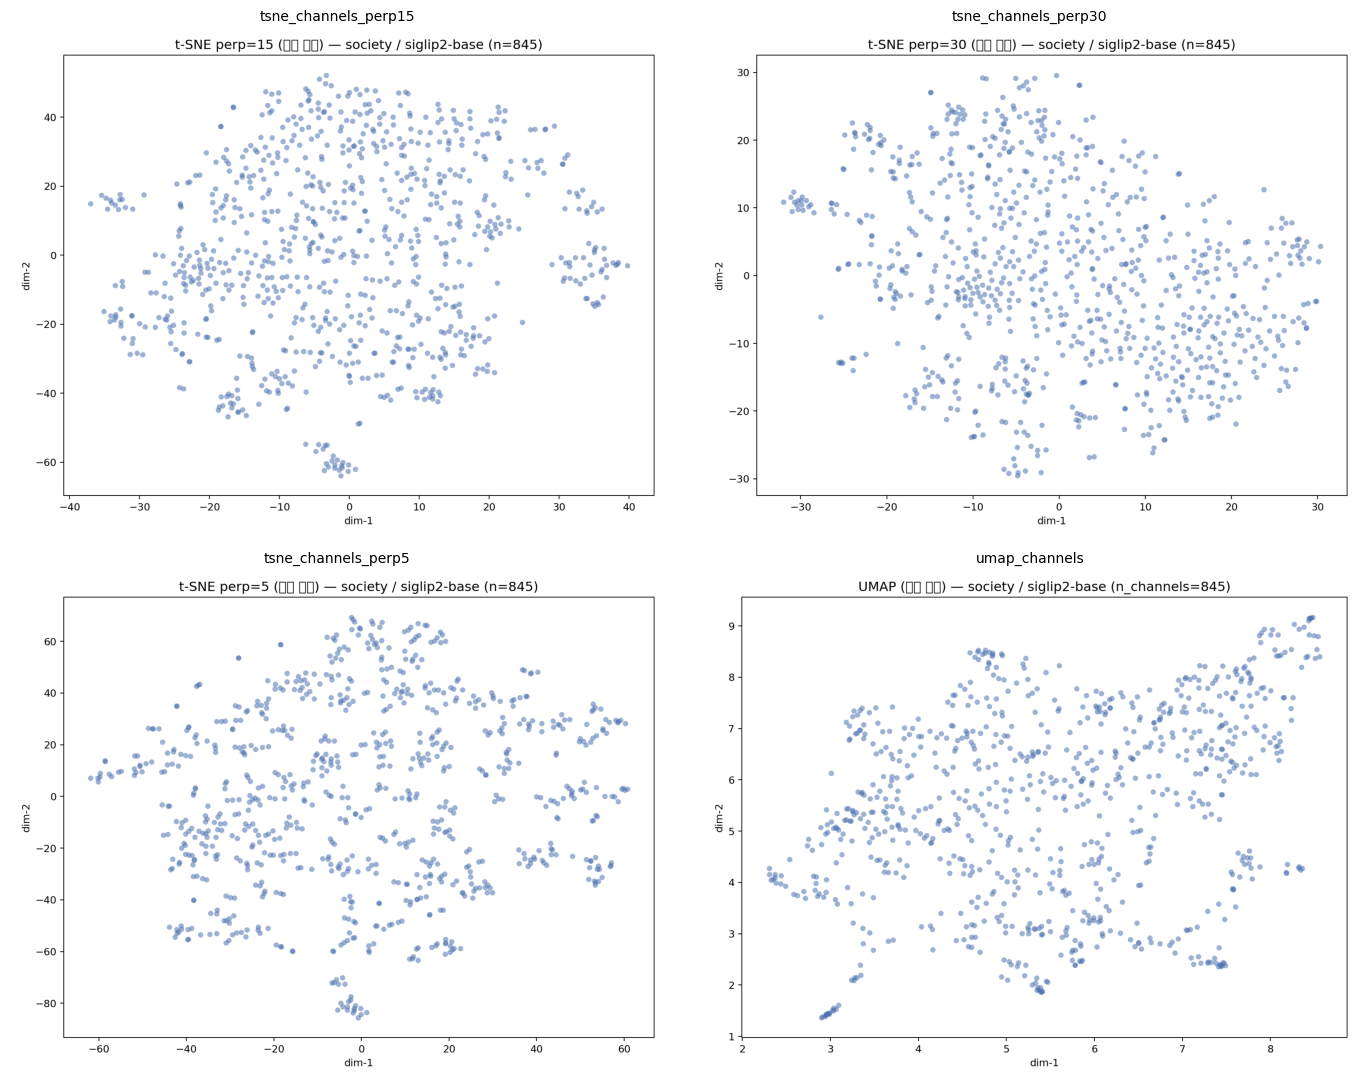


=== education / dinov2-base (채널 단위) ===


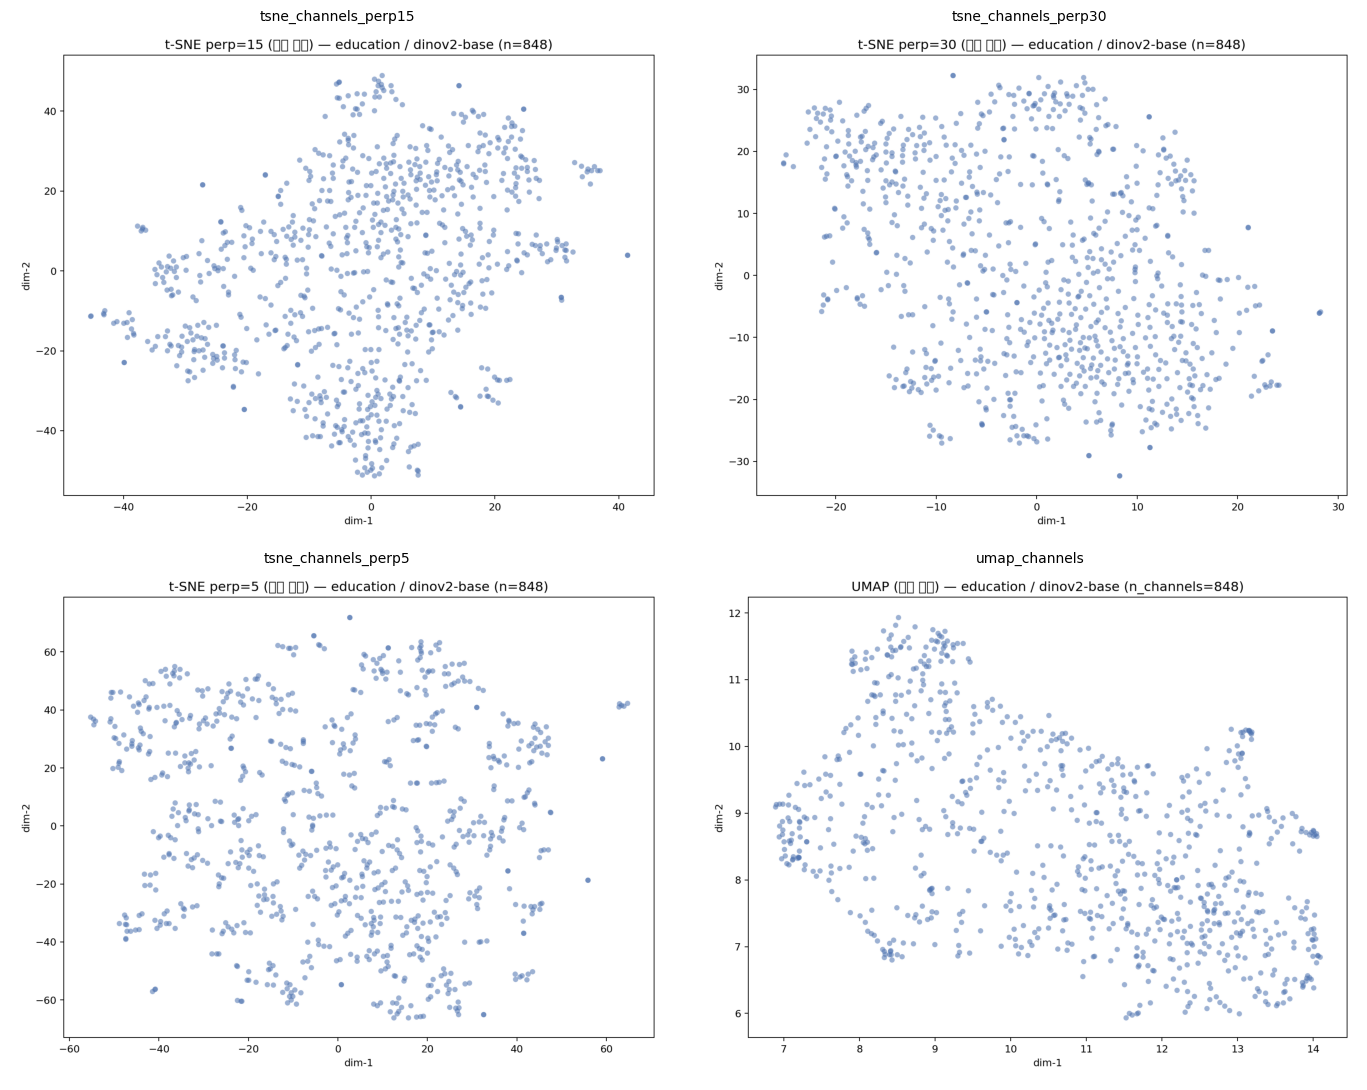


=== education / siglip2-base (채널 단위) ===


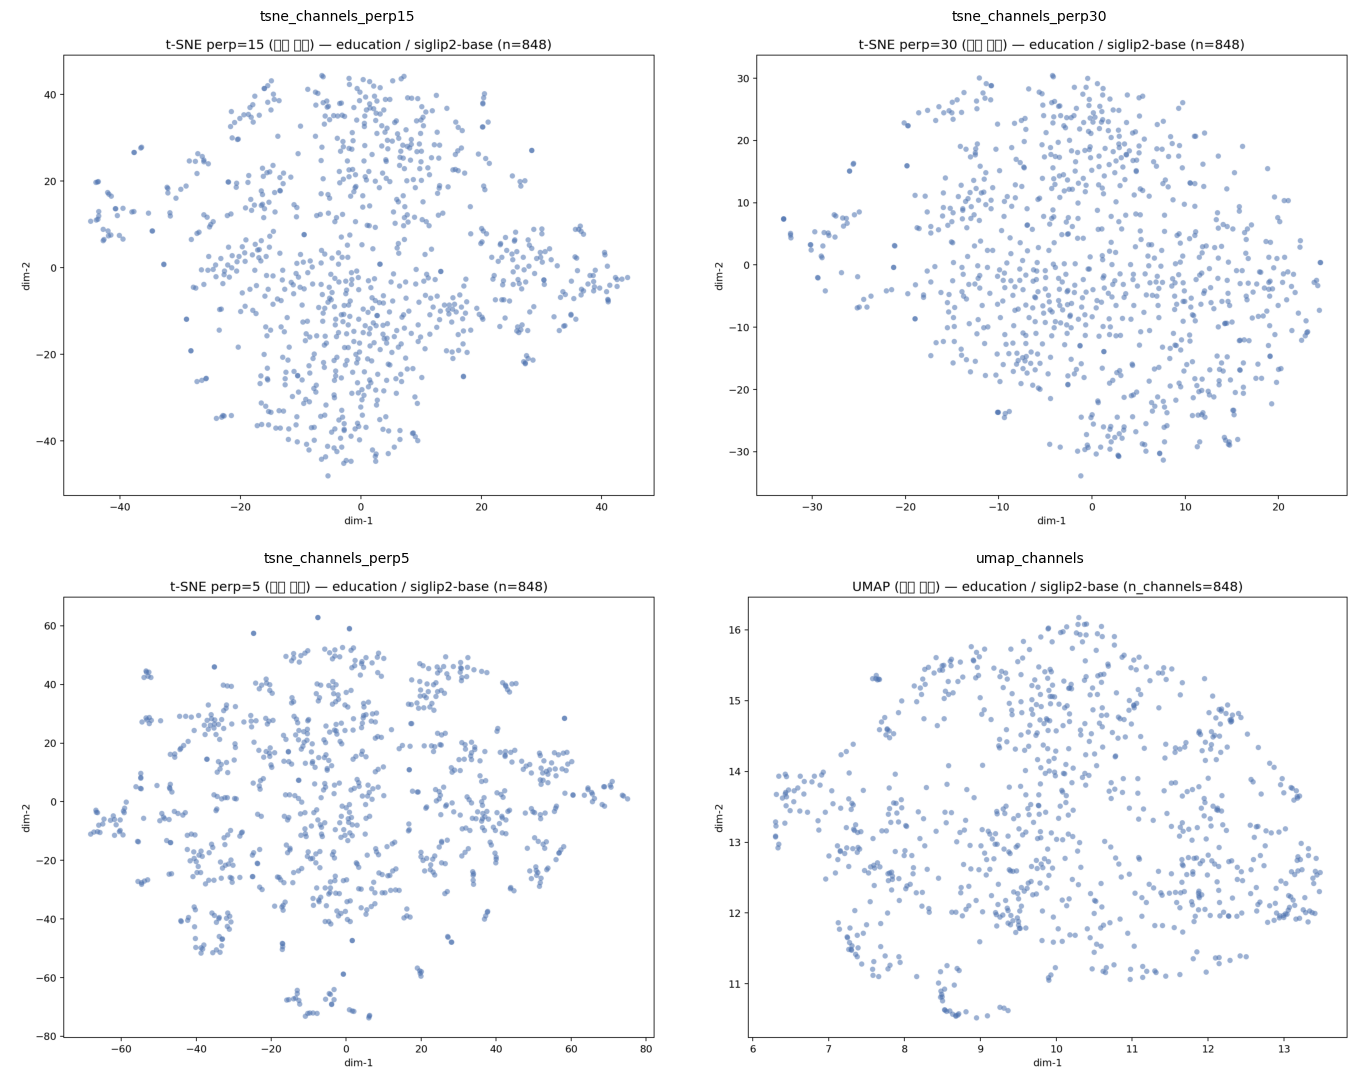

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def show_images(paths, cols: int = 2, title_prefix: str = "") -> None:
    paths = [Path(p) for p in paths if Path(p).exists()]
    if not paths:
        print("표시할 이미지가 없습니다.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5.5))
    axes = [axes] if rows * cols == 1 else list(
        axes.flat if hasattr(axes, "flat") else [axes]
    )
    for ax, p in zip(axes, paths):
        ax.imshow(mpimg.imread(p))
        ax.set_title(f"{title_prefix}{p.stem}", fontsize=10)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for cat, _ in DATASETS:
    viz = ARTIFACTS_BASE / cat / "visualizations"
    if not viz.is_dir():
        continue
    for model_dir in sorted(viz.iterdir()):
        if not model_dir.is_dir():
            continue
        imgs = sorted(model_dir.glob("*channels*.png"))
        if imgs:
            print(f"\n=== {cat} / {model_dir.name} (채널 단위) ===")
            show_images(imgs, cols=2)
